# Phase 2 : Aerodynamic Evaluation

**Project:** A data-driven surrogate for airfoil shape optimization, built on the AirfRANS benchmark

**Author:** Muhammad Uns Haider Shah

## Objective
Evaluate the two surrogates from Phases 1 and 1b (pointwise MLP and shape-aware MLP) on the quantities that matter for design, rather than on field error:

1. **Force coefficients.** Lift and drag, *including the viscous (skin-friction) contribution*, computed from the predicted fields with the same post-processing that produced the reference values.
2. **Ranking.** Spearman correlation of predicted vs. true $C_L$, $C_D$ and $L/D$ across the test set, and pairwise ordering accuracy between designs at **comparable operating conditions**, the situation an optimizer faces.
3. **Surface distributions.** Pressure coefficient $C_p$ and skin friction $C_f$.
4. **Boundary layers.** Velocity and eddy-viscosity profiles near the wall.
5. **Published baselines.** Comparison with the AirfRANS paper (Bonnet et al., NeurIPS 2022 Datasets and Benchmarks).

## Force post-processing
Following the AirfRANS protocol, predicted fields are written into the simulation object and passed to `Simulation.force_coefficient()`. Wall shear stress comes from the velocity gradient on the original CFD mesh, whose first cell is about 2 µm thick. Because velocity at a no-slip wall is known exactly (zero), drag is reported both from the **raw** prediction and with the **wall velocity set to zero** ("no-slip").

**Runtime:** Google Colab with a GPU (T4). Requires the Drive dataset cache and the Phase 1 and 1b checkpoints. Per-case results are saved to Drive as they are computed, so an interrupted run resumes where it stopped.

## 1. Environment

In [ ]:
# pyvista is pinned: 0.49+ requires a newer IPython than the Colab runtime provides
!pip install -q airfrans "pyvista==0.48.0" "vtk<9.7"
import airfrans as af
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch, torch.nn as nn
import os, glob, json, time, gc

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE, '|', torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'NO GPU: change the runtime type')
from scipy.spatial import cKDTree
from scipy.stats import spearmanr
from airfrans.naca_generator import camber_line, naca_generator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.4/242.4 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.0/273.0 kB 12.1 MB/s eta 0:00:00
device: cuda | Tesla T4


## 2. Configuration

In [ ]:
EVAL = dict(
    pair_daoa    = 1.0,      # "comparable conditions": |Δα| ≤ 1°
    pair_dre     = 0.5e6,    #                      and |ΔRe| ≤ 0.5 million
    pair_min_rel = 0.05,     # distinguishable pairs: true values differ by more than 5 %
    bl_stations  = [0.2, 0.5, 0.8],
    bl_height    = 0.04,     # length of the boundary-layer sampling line (chords)
)
IN_COLS, OUT_COLS, SURF_COL = [0, 1, 2, 3, 4, 5, 6], [7, 8, 9, 10], 11
OUT_NAMES = ['Ux', 'Uy', 'p', 'nut']

# Published results: Bonnet et al. (2022), Tables 2, 3 and 5. Mean over 5 training runs.
# Relative errors are means of |pred - true| / |true| (as fractions), as in the airfrans library.
PAPER = pd.DataFrame([
    dict(model='AirfRANS MLP (full, 800 cases)',        surf_p_mse=0.113,  cd_rel=4.289, cl_rel=0.767, rho_d=-0.117, rho_l=0.913),
    dict(model='AirfRANS GraphSAGE (scarce, 200 cases)', surf_p_mse=0.1945, cd_rel=3.504, cl_rel=0.385, rho_d=-0.139, rho_l=0.981),
]).set_index('model')
PAPER_VOL_SCARCE_GRAPHSAGE = dict(Ux=0.01457, Uy=0.01454, p=0.04696, nut=0.0611)

## 3. Dataset

In [ ]:
import shutil, zipfile
from google.colab import drive

USE_DRIVE = True
DRIVE_DIR = '/content/drive/MyDrive/airfrans'
DRIVE_ZIP = f'{DRIVE_DIR}/Dataset.zip'
ROOT_DL   = '/content/airfrans_data'
LOCAL_ZIP = f'{ROOT_DL}/Dataset.zip'

def have_data():
    return bool(glob.glob(f'{ROOT_DL}/**/manifest.json', recursive=True))

def gb(path):
    return os.path.getsize(path) / 1e9

if USE_DRIVE:
    drive.mount('/content/drive')
    os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(ROOT_DL, exist_ok=True)

if have_data():
    print('Dataset already extracted on this machine.')
elif USE_DRIVE and os.path.exists(DRIVE_ZIP):
    print(f'Copying {gb(DRIVE_ZIP):.1f} GB zip from Drive (unzipping from local disk is much faster)...')
    shutil.copy(DRIVE_ZIP, LOCAL_ZIP)
    print('Unzipping...')
    with zipfile.ZipFile(LOCAL_ZIP) as z:
        z.extractall(ROOT_DL)
else:
    print('No cached copy found. Downloading from the AirfRANS server (slow, one time only)...')
    af.dataset.download(root=ROOT_DL, file_name='Dataset', unzip=True, OpenFOAM=False)

# Cache to Drive if it isn't there yet. This only runs after a successful unzip,
# so a broken or partial download never gets saved.
if USE_DRIVE and os.path.exists(LOCAL_ZIP) and have_data():
    if not os.path.exists(DRIVE_ZIP) or gb(DRIVE_ZIP) != gb(LOCAL_ZIP):
        print(f'Saving {gb(LOCAL_ZIP):.1f} GB zip to Drive (10-20 min, one time only)...')
        shutil.copy(LOCAL_ZIP, DRIVE_ZIP)
    print(f'Drive copy OK: {gb(DRIVE_ZIP):.2f} GB  (local {gb(LOCAL_ZIP):.2f} GB)')

print('Data ready:', have_data())

Mounted at /content/drive
Copying 10.0 GB zip from Drive (unzipping from local disk is much faster)...
Unzipping...
Drive copy OK: 10.03 GB  (local 10.03 GB)
Data ready: True


In [ ]:
# The loader needs the folder that contains manifest.json. Find it rather than guessing.
ROOT = os.path.dirname(glob.glob(f'{ROOT_DL}/**/manifest.json', recursive=True)[0])
print('Dataset root:', ROOT)

# Free disk space: the zip is no longer needed locally once extracted
zip_path = f'{ROOT_DL}/Dataset.zip'
if os.path.exists(zip_path):
    os.remove(zip_path)

with open(f'{ROOT}/manifest.json') as f:
    manifest = json.load(f)
for k, v in manifest.items():
    print(f'{k:15s} {len(v):5d} simulations')

Dataset root: /content/airfrans_data/Dataset
full_train        800 simulations
scarce_train      200 simulations
reynolds_train    504 simulations
aoa_train         804 simulations
full_test         200 simulations
reynolds_test     496 simulations
aoa_test          196 simulations


## 4. Utilities

In [ ]:
import numpy as np

def order_surface(pos, normals):
    """Return indices that walk the airfoil surface as a closed loop:
    upper surface leading edge -> trailing edge, then lower surface trailing edge -> leading edge.
    Works whichever way the normals point (inward or outward)."""
    g1 = np.where(normals[:, 1] < 0)[0]
    g2 = np.where(normals[:, 1] >= 0)[0]
    # The upper-surface group is the one sitting higher on average
    upper, lower = (g1, g2) if pos[g1, 1].mean() > pos[g2, 1].mean() else (g2, g1)
    upper = upper[np.argsort(pos[upper, 0])]     # LE -> TE
    lower = lower[np.argsort(-pos[lower, 0])]    # TE -> LE
    return np.concatenate([upper, lower]), len(upper)

def pressure_force_coefficients(pos, normals, p, u_inf, aoa_rad):
    """Integrate surface pressure (kinematic, p/rho) to pressure-only lift and drag coefficients.
    pos, normals, p: surface nodes only. Returns (cd_p, cl_p)."""
    idx, _ = order_surface(pos, normals)
    P, N, pp = pos[idx], normals[idx], p[idx].ravel()
    # Length "owned" by each node = half of each neighbouring segment on the closed loop
    seg = np.linalg.norm(np.roll(P, -1, axis=0) - P, axis=1)
    L = 0.5 * (seg + np.roll(seg, 1))
    # Make normals point OUT of the body: on average they should point away from the centroid
    sign = np.sign(np.mean(np.sum((P - P.mean(axis=0)) * N, axis=1)))
    n_out = sign * N / np.linalg.norm(N, axis=1, keepdims=True)
    F = -(pp[:, None] * n_out * L[:, None]).sum(axis=0)       # force / rho
    drag_dir = np.array([np.cos(aoa_rad), np.sin(aoa_rad)])
    lift_dir = np.array([-np.sin(aoa_rad), np.cos(aoa_rad)])
    q = 0.5 * u_inf**2
    return F @ drag_dir / q, F @ lift_dir / q

def parse_name(name):
    """AirfRANS names look like airFoil2D_SST_<Uinf>_<AoA deg>_<NACA params...>"""
    parts = name.split('_')
    u_inf, aoa = float(parts[2]), float(parts[3])
    naca = [float(v) for v in parts[4:]]
    return u_inf, aoa, naca


In [ ]:
def shape_descriptor(naca):
    naca = np.asarray(naca, dtype=float)
    if len(naca) == 3:
        params_c, t = naca[:2], naca[2] / 100
    elif len(naca) == 4:
        params_c, t = naca[:3], naca[3] / 100
    else:
        raise ValueError(f'unexpected NACA parameters {naca}')
    y_c, _ = camber_line(params_c, STATIONS.copy())
    return np.concatenate([[t], y_c]).astype(np.float32)

family = lambda n: '4-digit' if len(parse_name(n)[2]) == 3 else '5-digit'

## 5. Models
Both checkpoints are restored with their own configurations and normalisation statistics.

In [ ]:
class PointwiseMLP(nn.Module):
    def __init__(self, n_in, n_out, width, depth):
        super().__init__()
        layers, d = [], n_in
        for _ in range(depth):
            layers += [nn.Linear(d, width), nn.GELU()]
            d = width
        layers.append(nn.Linear(d, n_out))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


P1_DIR  = os.path.join(DRIVE_DIR if USE_DRIVE else '/content', 'phase1')
P1B_DIR = os.path.join(DRIVE_DIR if USE_DRIVE else '/content', 'phase1b')
OUT_DIR = os.path.join(DRIVE_DIR if USE_DRIVE else '/content', 'phase2')
os.makedirs(OUT_DIR, exist_ok=True)

def restore(path, n_in):
    ck = torch.load(path, map_location=DEVICE, weights_only=False)
    net = PointwiseMLP(n_in, 4, ck['cfg']['width'], ck['cfg']['depth']).to(DEVICE)
    net.load_state_dict(ck['model']); net.eval()
    stats = {k: np.array(v, dtype=np.float32) for k, v in ck['stats'].items()}
    return net, stats, ck['cfg']

net_pw, st_pw, cfg_pw = restore(f'{P1_DIR}/mlp_best.pt', 7)
ck_sa_cfg = torch.load(f'{P1B_DIR}/mlp_shape_best.pt', map_location='cpu', weights_only=False)['cfg']
STATIONS = np.array(ck_sa_cfg['stations'])
G_NAMES = ['t'] + [f'yc@{x:g}' for x in STATIONS]
net_sa, st_sa, cfg_sa = restore(f'{P1B_DIR}/mlp_shape_best.pt', 7 + len(G_NAMES))

with open(f'{P1_DIR}/phase1_summary.json') as f:  sum_pw = json.load(f)
with open(f'{P1B_DIR}/phase1b_summary.json') as f: sum_sa = json.load(f)
use_amp = DEVICE.type == 'cuda'
print('pointwise   :', sum(p.numel() for p in net_pw.parameters()), 'parameters')
print('shape-aware :', sum(p.numel() for p in net_sa.parameters()), 'parameters')

@torch.no_grad()
def run_net(net, X, chunk=400_000):
    X = torch.from_numpy(X.astype(np.float32)).to(DEVICE)
    outs = []
    for i in range(0, len(X), chunk):
        with torch.autocast(DEVICE.type, dtype=torch.float16, enabled=use_amp):
            outs.append(net(X[i:i + chunk]).float())
    return torch.cat(outs).cpu().numpy()

def predict(model, arr, name):
    # Physical fields (N, 4) predicted by 'pw' or 'sa' for one case
    if model == 'pw':
        X = (arr[:, IN_COLS] - st_pw['x_mean']) / st_pw['x_std']
        return run_net(net_pw, X) * st_pw['y_std'] + st_pw['y_mean']
    g = (shape_descriptor(parse_name(name)[2]) - st_sa['g_mean']) / st_sa['g_std']
    X = np.hstack([(arr[:, IN_COLS] - st_sa['x_mean']) / st_sa['x_std'],
                   np.broadcast_to(g, (len(arr), len(g)))])
    return run_net(net_sa, X) * st_sa['y_std'] + st_sa['y_mean']

pointwise   : 266244 parameters
shape-aware : 269572 parameters


## 6. Force coefficients on the test set
For each of the 200 test cases, five force evaluations are made: the reference fields, and each model's prediction with raw and with no-slip wall velocity. Surface pressure is identical in both variants, so it is evaluated once per model. Results are appended to a CSV on Drive every 10 cases.

In [ ]:
def sim_to_array(sim):
    u_in = (np.array([np.cos(sim.angle_of_attack), np.sin(sim.angle_of_attack)])
            * sim.inlet_velocity).reshape(1, 2) * np.ones_like(sim.sdf)
    return np.concatenate([sim.position, u_in, sim.sdf, sim.normals, sim.velocity,
                           sim.pressure, sim.nu_t, sim.surface.reshape(-1, 1)], axis=-1).astype(np.float32)

def set_fields(sim, P, no_slip):
    U = P[:, :2].astype(np.float64).copy()
    if no_slip:
        U[sim.surface] = 0.0
    sim.velocity = U
    sim.pressure = P[:, 2:3].astype(np.float64)
    sim.nu_t = P[:, 3:4].astype(np.float64)

def coeffs(sim, prefix, reference=False):
    (cd, cdp, cdv), (cl, clp, clv) = sim.force_coefficient(reference=reference)
    return {f'{prefix}_cd': cd, f'{prefix}_cdp': cdp, f'{prefix}_cdv': cdv,
            f'{prefix}_cl': cl, f'{prefix}_clp': clp, f'{prefix}_clv': clv}

CSV = f'{OUT_DIR}/test_forces.csv'
done = pd.read_csv(CSV) if os.path.exists(CSV) else pd.DataFrame()
done_names = set(done['name']) if len(done) else set()
test_names = manifest['full_test']
todo = [n for n in test_names if n not in done_names]
print(f'{len(done_names)} cases already evaluated, {len(todo)} to go')

rows, t0 = [], time.time()
for k, name in enumerate(todo):
    sim = af.Simulation(root=ROOT, name=name)
    arr = sim_to_array(sim)
    u, aoa, naca = parse_name(name)
    q = 0.5 * u ** 2
    s = arr[:, SURF_COL] > 0.5
    row = dict(name=name, u_inf=u, aoa=aoa, re=u / float(sim.NU), family=family(name))
    row.update(coeffs(sim, 'true', reference=True))
    for m in ('pw', 'sa'):
        P = predict(m, arr, name)
        row[f'{m}_cp_rmse'] = float(np.sqrt(np.mean(((P[s, 2] - arr[s, 9]) / q) ** 2)))
        for no_slip, tag in ((False, 'raw'), (True, 'ns')):
            set_fields(sim, P, no_slip)
            row.update(coeffs(sim, f'{m}_{tag}'))
    rows.append(row)
    if len(rows) == 10 or k == len(todo) - 1:
        done = pd.concat([done, pd.DataFrame(rows)], ignore_index=True)
        done.to_csv(CSV, index=False)
        rows = []
        el = time.time() - t0
        print(f'  {k + 1}/{len(todo)} cases | {el:.0f} s elapsed | ~{el / (k + 1) * (len(todo) - k - 1):.0f} s left')

res = pd.read_csv(CSV).set_index('name').loc[test_names].reset_index()
assert len(res) == len(test_names)
for m in ('true', 'pw_raw', 'pw_ns', 'sa_raw', 'sa_ns'):
    res[f'{m}_ld'] = res[f'{m}_cl'] / res[f'{m}_cd']
print(f'{len(res)} test cases evaluated')

0 cases already evaluated, 200 to go
  10/200 cases | 56 s elapsed | ~1063 s left
  20/200 cases | 91 s elapsed | ~815 s left
  30/200 cases | 130 s elapsed | ~739 s left
  40/200 cases | 171 s elapsed | ~685 s left
  50/200 cases | 207 s elapsed | ~621 s left
  60/200 cases | 244 s elapsed | ~570 s left
  70/200 cases | 279 s elapsed | ~519 s left
  80/200 cases | 317 s elapsed | ~475 s left
  90/200 cases | 357 s elapsed | ~436 s left
  100/200 cases | 393 s elapsed | ~393 s left
  110/200 cases | 432 s elapsed | ~353 s left
  120/200 cases | 467 s elapsed | ~311 s left
  130/200 cases | 505 s elapsed | ~272 s left
  140/200 cases | 546 s elapsed | ~234 s left
  150/200 cases | 582 s elapsed | ~194 s left
  160/200 cases | 621 s elapsed | ~155 s left
  170/200 cases | 655 s elapsed | ~116 s left
  180/200 cases | 694 s elapsed | ~77 s left
  190/200 cases | 729 s elapsed | ~38 s left
  200/200 cases | 765 s elapsed | ~0 s left
200 test cases evaluated


## 7. Force-coefficient accuracy and ranking
Relative errors follow the AirfRANS definition, the mean (± standard deviation) over the test set of $|\hat{C} - C| / |C|$. This mean is dominated by cases whose coefficient is close to zero, so the median is also given. Spearman's $\rho$ measures how well each model **orders** the 200 test cases.

In [ ]:
VARIANTS = [('pw_raw', 'pointwise, raw'), ('pw_ns', 'pointwise, no-slip'),
            ('sa_raw', 'shape-aware, raw'), ('sa_ns', 'shape-aware, no-slip')]

def rel(m, c):
    return (res[f'{m}_{c}'] - res[f'true_{c}']).abs() / res[f'true_{c}'].abs()

table = []
for m, lab in VARIANTS:
    r = dict(model=lab)
    for c, C in (('cd', 'CD'), ('cl', 'CL')):
        e = rel(m, c)
        r[f'{C} rel. err (mean ± std)'] = f'{e.mean():.3f} ± {e.std():.3f}'
        r[f'{C} rel. err (median)'] = f'{e.median():.3f}'
    for c, C in (('cd', 'ρ_D'), ('cl', 'ρ_L'), ('ld', 'ρ_L/D')):
        r[C] = f"{spearmanr(res[f'{m}_{c}'], res[f'true_{c}'])[0]:.3f}"
    table.append(r)
force_table = pd.DataFrame(table).set_index('model')
print(force_table.T.to_string())

model                      pointwise, raw pointwise, no-slip shape-aware, raw shape-aware, no-slip
CD rel. err (mean ± std)  23.210 ± 11.877    23.332 ± 11.967   18.158 ± 7.815       18.153 ± 7.832
CD rel. err (median)               22.112             22.139           17.187               17.152
CL rel. err (mean ± std)    0.296 ± 0.738      0.296 ± 0.737    0.096 ± 0.221        0.096 ± 0.220
CL rel. err (median)                0.104              0.107            0.026                0.026
ρ_D                                -0.015             -0.019            0.077                0.075
ρ_L                                 0.985              0.985            0.998                0.998
ρ_L/D                               0.860              0.860            0.882                0.883


**Where drag error comes from.** Drag is split into its pressure and viscous parts, each compared with its reference counterpart (median relative error).

In [ ]:
split = pd.DataFrame({lab: {'pressure drag CDp': rel(m, 'cdp').median(),
                             'viscous drag CDv': rel(m, 'cdv').median(),
                             'total drag CD': rel(m, 'cd').median()}
                       for m, lab in VARIANTS})
print(split.round(3).to_string())
print(f"\nreference: viscous drag is {np.median(res['true_cdv'] / res['true_cd']) * 100:.0f} % of total drag (median over test cases)")

                   pointwise, raw  pointwise, no-slip  shape-aware, raw  shape-aware, no-slip
pressure drag CDp           6.980               6.980             0.602                 0.602
viscous drag CDv           36.133              36.266            27.087                27.057
total drag CD              22.112              22.139            17.187                17.152

reference: viscous drag is 68 % of total drag (median over test cases)


## 8. Comparison with the published baselines
The AirfRANS values are means over five training runs, taken from the paper. This work reports single training runs. Normalised field MSEs depend on the normalisation statistics, which here come from 160 of the 200 scarce training cases, so those comparisons are approximate. Force coefficients and rank correlations do not depend on normalisation.

The paper's MLP row was trained on the *full* task (4× more data); its GraphSAGE row is the paper's result for the same *scarce* task used here.

In [ ]:
ours = []
for m, lab, summ in (('pw_ns', 'This work: pointwise MLP (scarce)', sum_pw),
                     ('sa_ns', 'This work: shape-aware MLP (scarce)', sum_sa)):
    ours.append(dict(model=lab, surf_p_mse=summ['test_surface_mse']['p'],
                     cd_rel=rel(m, 'cd').mean(), cl_rel=rel(m, 'cl').mean(),
                     rho_d=spearmanr(res[f'{m}_cd'], res['true_cd'])[0],
                     rho_l=spearmanr(res[f'{m}_cl'], res['true_cl'])[0]))
comparison = pd.concat([PAPER, pd.DataFrame(ours).set_index('model')])
comparison.columns = ['surface p MSE', 'CD rel. err', 'CL rel. err', 'ρ_D', 'ρ_L']
print(comparison.to_string(float_format=lambda v: f'{v:.3f}'))
print('\nThis work: no-slip variant. Relative errors are means, as in the paper.')

vol = pd.DataFrame({'AirfRANS GraphSAGE (scarce)': PAPER_VOL_SCARCE_GRAPHSAGE,
                    'this work: pointwise': sum_pw['test_volume_mse'],
                    'this work: shape-aware': sum_sa['test_volume_mse']})
print('\nvolume MSE (normalised fields)')
print(vol.to_string(float_format=lambda v: f'{v:.4f}'))

                                        surface p MSE  CD rel. err  CL rel. err    ρ_D   ρ_L
model                                                                                       
AirfRANS MLP (full, 800 cases)                  0.113        4.289        0.767 -0.117 0.913
AirfRANS GraphSAGE (scarce, 200 cases)          0.195        3.504        0.385 -0.139 0.981
This work: pointwise MLP (scarce)               0.967       23.332        0.296 -0.019 0.985
This work: shape-aware MLP (scarce)             0.063       18.153        0.096  0.075 0.998

This work: no-slip variant. Relative errors are means, as in the paper.

volume MSE (normalised fields)
     AirfRANS GraphSAGE (scarce)  this work: pointwise  this work: shape-aware
Ux                        0.0146                0.2118                  0.0659
Uy                        0.0145                0.1932                  0.0802
p                         0.0470                0.3601                  0.0388
nut                  

## 9. Parity plots

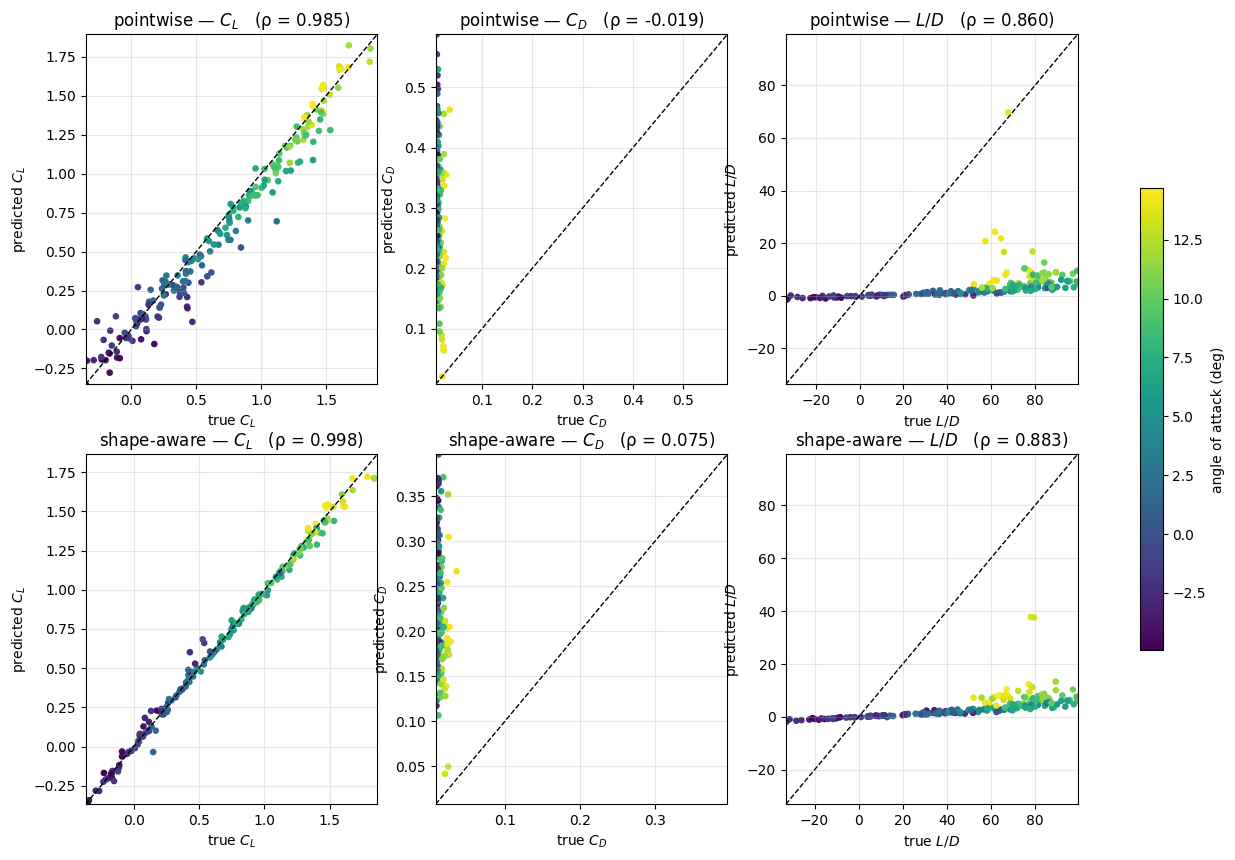

axes clipped to the 1st–99th percentile range


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for row, (m, lab) in enumerate((('pw_ns', 'pointwise'), ('sa_ns', 'shape-aware'))):
    for col, (c, C) in enumerate((('cl', '$C_L$'), ('cd', '$C_D$'), ('ld', '$L/D$'))):
        a = axes[row, col]
        x, y = res[f'true_{c}'], res[f'{m}_{c}']
        sc = a.scatter(x, y, c=res['aoa'], cmap='viridis', s=14)
        lo, hi = np.percentile(np.r_[x, y], [1, 99])
        a.plot([lo, hi], [lo, hi], 'k--', lw=1)
        a.set_xlim(lo, hi); a.set_ylim(lo, hi)
        a.set_xlabel(f'true {C}'); a.set_ylabel(f'predicted {C}')
        a.set_title(f'{lab} — {C}   (ρ = {spearmanr(x, y)[0]:.3f})'); a.grid(alpha=0.3)
fig.colorbar(sc, ax=axes, label='angle of attack (deg)', shrink=0.6)
plt.savefig(f'{OUT_DIR}/parity_forces.png', dpi=150, bbox_inches='tight'); plt.show()
print('axes clipped to the 1st–99th percentile range')

## 10. Ranking at comparable operating conditions
Across the whole test set, lift is ordered mostly by angle of attack, which every model receives as an input. An optimizer instead compares **different shapes at the same condition**. The test set contains no such pairs by construction, so the closest available proxy is used: all pairs of test cases whose angle of attack and Reynolds number both lie within the windows set in the configuration. For each pair, the check is whether the model orders the two designs correctly.

Pairs whose true values are almost equal are close to a coin toss for any model, so accuracy is also reported for **distinguishable** pairs, whose true values differ by more than 5 %.

In [ ]:
i, j = np.triu_indices(len(res), 1)
near = (np.abs(res['aoa'].values[i] - res['aoa'].values[j]) <= EVAL['pair_daoa']) & \
       (np.abs(res['re'].values[i] - res['re'].values[j]) <= EVAL['pair_dre'])

def pair_acc(m, c, mask):
    t, p = res[f'true_{c}'].values, res[f'{m}_{c}'].values
    ok = np.sign(t[i] - t[j]) == np.sign(p[i] - p[j])
    dist = np.abs(t[i] - t[j]) > EVAL['pair_min_rel'] * np.maximum(np.abs(t[i]), np.abs(t[j]))
    frac = lambda sel: ok[sel].mean() if sel.any() else np.nan
    return frac(mask), frac(mask & dist), (mask & dist).sum()

rows = []
for m, lab in VARIANTS:
    r = dict(model=lab)
    for c, C in (('cl', 'CL'), ('cd', 'CD'), ('ld', 'L/D')):
        a_all, _, _ = pair_acc(m, c, np.ones_like(near))
        a_near, a_dist, n_dist = pair_acc(m, c, near)
        r[f'{C}: all pairs'] = a_all
        r[f'{C}: comparable'] = a_near
        r[f'{C}: comparable & distinguishable'] = a_dist
    rows.append(r)
pairs = pd.DataFrame(rows).set_index('model')
print(f'{len(i)} pairs in total; {near.sum()} at comparable conditions '
      f'(|Δα| ≤ {EVAL["pair_daoa"]}°, |ΔRe| ≤ {EVAL["pair_dre"] / 1e6:g} M)')
print('fraction of pairs ordered correctly (0.5 = chance)\n')
print(pairs.T.to_string(float_format=lambda v: f'{v:.3f}'))

19900 pairs in total; 479 at comparable conditions (|Δα| ≤ 1.0°, |ΔRe| ≤ 0.5 M)
fraction of pairs ordered correctly (0.5 = chance)

model                              pointwise, raw  pointwise, no-slip  shape-aware, raw  shape-aware, no-slip
CL: all pairs                               0.951               0.952             0.984                 0.984
CL: comparable                              0.902               0.902             0.971                 0.971
CL: comparable & distinguishable            0.919               0.919             0.988                 0.988
CD: all pairs                               0.501               0.499             0.526                 0.526
CD: comparable                              0.576               0.580             0.626                 0.628
CD: comparable & distinguishable            0.571               0.576             0.658                 0.658
L/D: all pairs                              0.842               0.842             0.866           

## 11. Surface pressure and skin friction
A representative test case: the one with the median lift error of the shape-aware model. $C_f$ is the chordwise component of the wall shear stress divided by $\tfrac12 u_\infty^2$, computed from each model's no-slip velocity field.

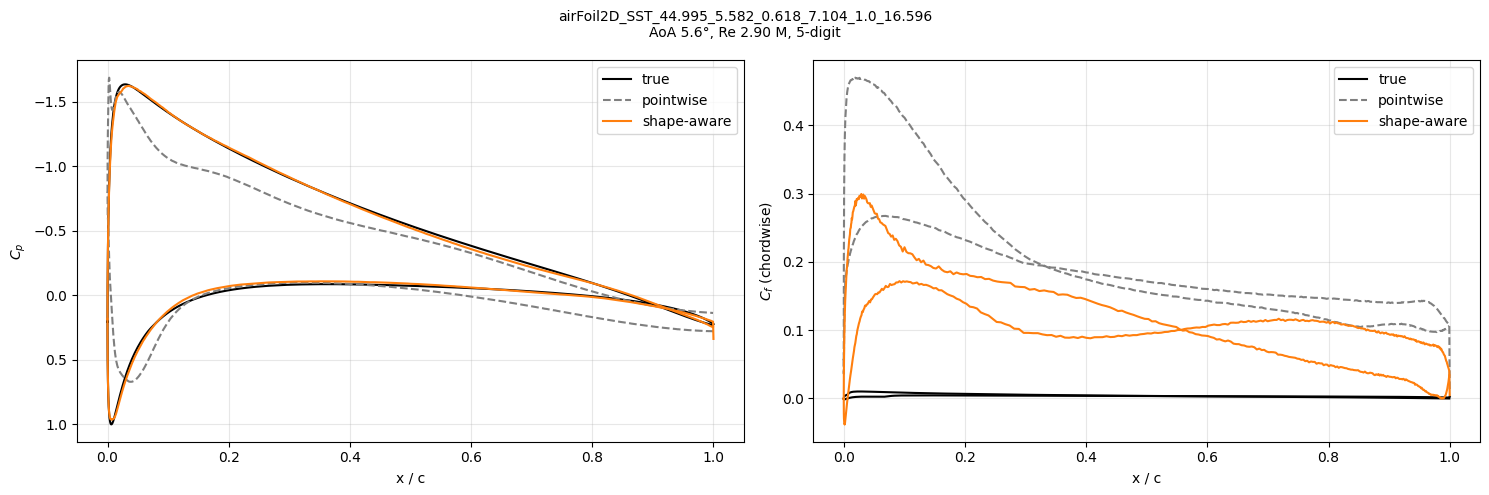

CL: true 0.6364 | pointwise 0.5449 | shape-aware 0.6197
CD: true 0.01158 | pointwise 0.35932 | shape-aware 0.23981


In [ ]:
err_sa = (res['sa_ns_cl'] - res['true_cl']).abs()
k_med = int((err_sa - err_sa.median()).abs().idxmin())
name = res.loc[k_med, 'name']
sim = af.Simulation(root=ROOT, name=name)
arr = sim_to_array(sim)
u, aoa, naca = parse_name(name)
q = 0.5 * u ** 2
s = arr[:, SURF_COL] > 0.5
idx, n_up = order_surface(arr[s, :2], arr[s, 5:7])
xs = arr[s, 0][idx]

curves = {'true': (arr[:, 7:11], 'k', '-')}
curves['pointwise'] = (predict('pw', arr, name), 'tab:gray', '--')
curves['shape-aware'] = (predict('sa', arr, name), 'tab:orange', '-')

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for lab, (P, col, ls) in curves.items():
    cp = P[s, 2][idx] / q
    if lab == 'true':
        wss = sim.wallshearstress(reference=True)
    else:
        set_fields(sim, P, no_slip=True)
        wss = sim.wallshearstress()
    cf = wss[s, 0][idx] / q
    for part in (slice(0, n_up), slice(n_up, None)):
        ax[0].plot(xs[part], cp[part], color=col, linestyle=ls, label=lab if part.start == 0 else None)
        ax[1].plot(xs[part], cf[part], color=col, linestyle=ls, label=lab if part.start == 0 else None)
ax[0].invert_yaxis(); ax[0].set_ylabel('$C_p$')
ax[1].set_ylabel('$C_f$ (chordwise)')
for a in ax:
    a.set_xlabel('x / c'); a.grid(alpha=0.3); a.legend()
fig.suptitle(f'{name}\nAoA {aoa:.1f}°, Re {res.loc[k_med, "re"] / 1e6:.2f} M, {family(name)}', fontsize=10)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/surface_cp_cf.png', dpi=150, bbox_inches='tight'); plt.show()
r = res.loc[k_med]
print(f"CL: true {r.true_cl:.4f} | pointwise {r.pw_ns_cl:.4f} | shape-aware {r.sa_ns_cl:.4f}")
print(f"CD: true {r.true_cd:.5f} | pointwise {r.pw_ns_cd:.5f} | shape-aware {r.sa_ns_cd:.5f}")

## 12. Boundary-layer profiles
Suction-side profiles for the same case, sampled along vertical lines from the wall at three chord stations: streamwise velocity $u/u_\infty$ and eddy-viscosity ratio $\nu_t/\nu$.

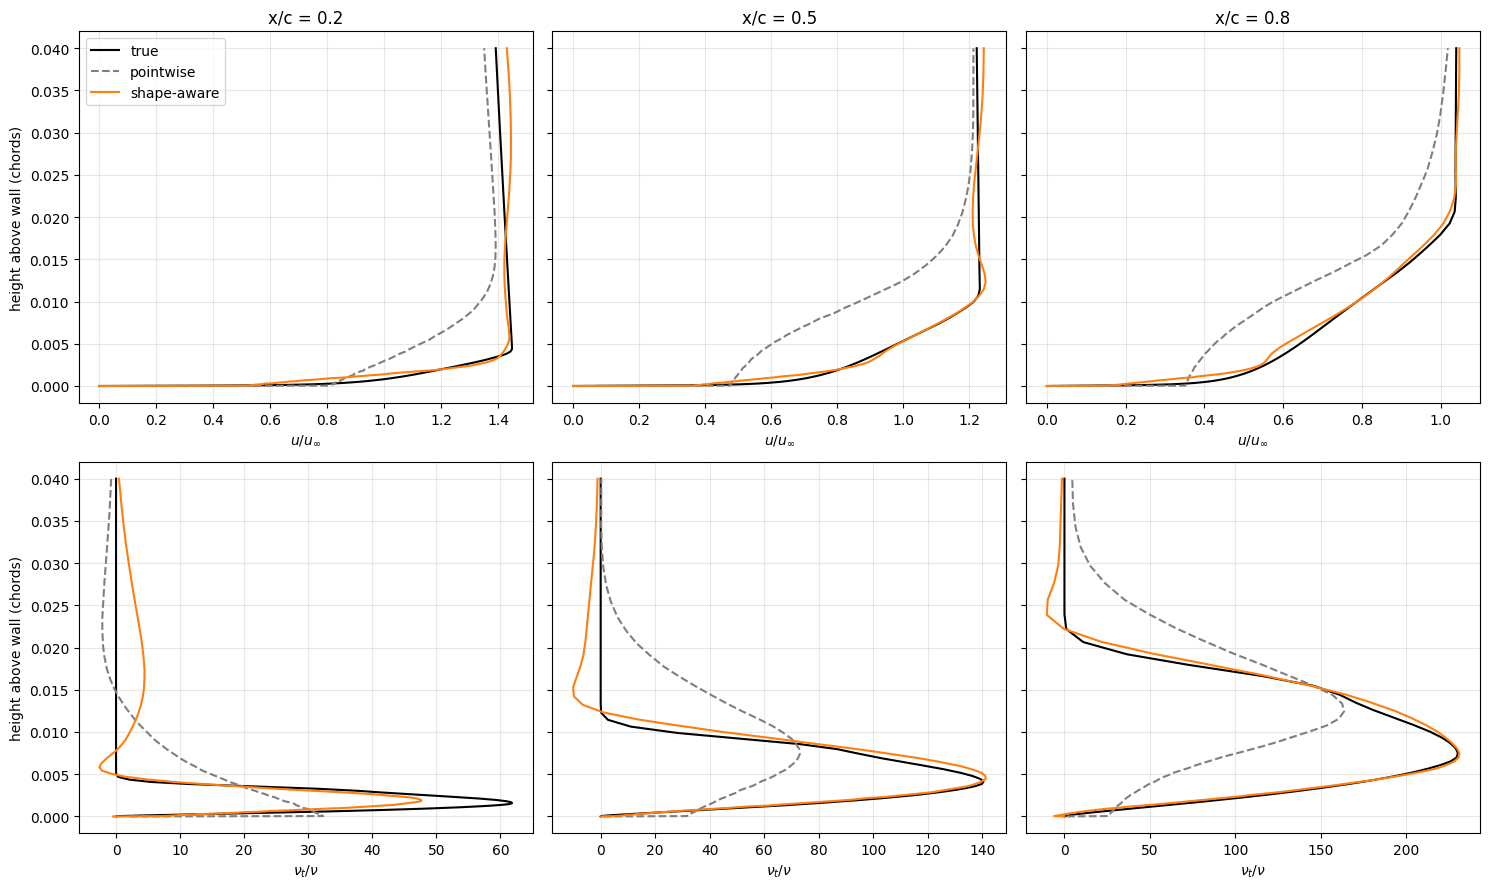

In [ ]:
st = EVAL['bl_stations']
fig, axes = plt.subplots(2, len(st), figsize=(5 * len(st), 9), sharey=True)
for lab, (P, col, ls) in curves.items():
    if lab != 'true':
        set_fields(sim, P, no_slip=True)
    for kx, x in enumerate(st):
        yc, ub, vb, pb, nb = sim.boundary_layer(x, y=EVAL['bl_height'], extrado=True,
                                                reference=(lab == 'true'))
        axes[0, kx].plot(ub, yc, color=col, linestyle=ls, label=lab)
        axes[1, kx].plot(nb, yc, color=col, linestyle=ls, label=lab)
for kx, x in enumerate(st):
    axes[0, kx].set_title(f'x/c = {x}')
    axes[0, kx].set_xlabel('$u / u_\\infty$'); axes[1, kx].set_xlabel('$\\nu_t / \\nu$')
    for a in axes[:, kx]:
        a.grid(alpha=0.3)
axes[0, 0].set_ylabel('height above wall (chords)'); axes[1, 0].set_ylabel('height above wall (chords)')
axes[0, 0].legend()
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/boundary_layers.png', dpi=150, bbox_inches='tight'); plt.show()

## 13. Error across operating conditions
Shape-aware model (no-slip): absolute lift error and relative drag error against angle of attack and Reynolds number.

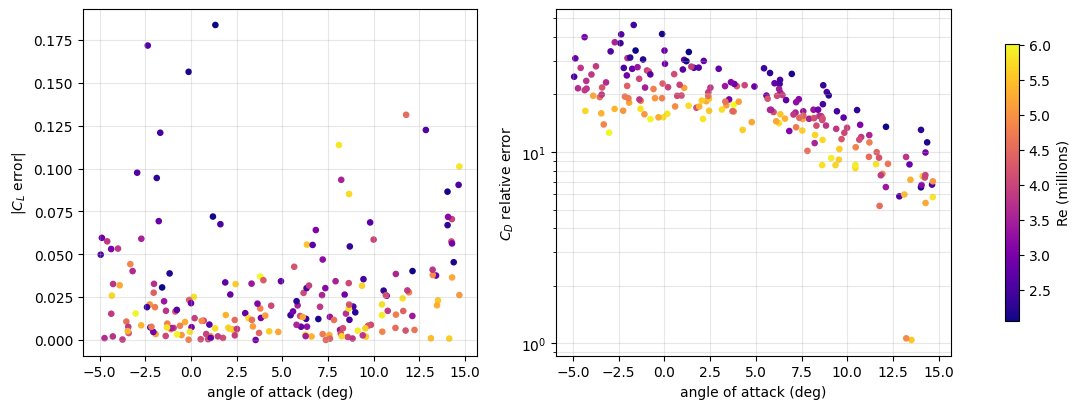

median errors by family (shape-aware, no-slip)
         cl_abs   cd_rel
family                  
4-digit  0.0200  16.8078
5-digit  0.0145  17.2712


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sc = ax[0].scatter(res['aoa'], (res['sa_ns_cl'] - res['true_cl']).abs(), c=res['re'] / 1e6, cmap='plasma', s=14)
ax[0].set_xlabel('angle of attack (deg)'); ax[0].set_ylabel('|$C_L$ error|')
ax[1].scatter(res['aoa'], rel('sa_ns', 'cd'), c=res['re'] / 1e6, cmap='plasma', s=14)
ax[1].set_xlabel('angle of attack (deg)'); ax[1].set_ylabel('$C_D$ relative error'); ax[1].set_yscale('log')
for a in ax:
    a.grid(alpha=0.3, which='both')
fig.colorbar(sc, ax=ax, label='Re (millions)', shrink=0.8)
plt.savefig(f'{OUT_DIR}/error_vs_conditions.png', dpi=150, bbox_inches='tight'); plt.show()

print('median errors by family (shape-aware, no-slip)')
print(res.assign(cl_abs=(res['sa_ns_cl'] - res['true_cl']).abs(), cd_rel=rel('sa_ns', 'cd'))
         .groupby('family')[['cl_abs', 'cd_rel']].median().round(4).to_string())

## 14. Saved artefacts

In [ ]:
summary = dict(eval=EVAL,
               force_table=force_table.reset_index().to_dict(orient='records'),
               drag_split_median=split.to_dict(),
               comparison=comparison.reset_index().to_dict(orient='records'),
               pairwise=pairs.reset_index().to_dict(orient='records'),
               n_pairs_total=int(len(i)), n_pairs_comparable=int(near.sum()),
               example_case=name)
with open(f'{OUT_DIR}/phase2_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=float)
for p in sorted(glob.glob(f'{OUT_DIR}/*')):
    print(f'{os.path.getsize(p) / 1e6:8.2f} MB  {p}')

    0.24 MB  /content/drive/MyDrive/airfrans/phase2/boundary_layers.png
    0.13 MB  /content/drive/MyDrive/airfrans/phase2/error_vs_conditions.png
    0.28 MB  /content/drive/MyDrive/airfrans/phase2/parity_forces.png
    0.01 MB  /content/drive/MyDrive/airfrans/phase2/phase2_summary.json
    0.17 MB  /content/drive/MyDrive/airfrans/phase2/surface_cp_cf.png
    0.15 MB  /content/drive/MyDrive/airfrans/phase2/test_forces.csv


## Summary
Both surrogates are evaluated on the 200-case test set through the same force post-processing as the reference data. The analysis covers lift and drag accuracy with a breakdown into pressure and viscous drag, rank correlation across the test set, pairwise ordering of designs at comparable operating conditions, surface $C_p$ and $C_f$, boundary-layer profiles, and a comparison with the published AirfRANS baselines.

The key question for the next phase is which quantities a model ranks reliably. That determines which objective a surrogate-driven optimization can trust.

**Results.** Lift is predicted and ranked well; drag is not.

| shape-aware model, 200 test cases | value |
|---|---|
| lift relative error, median | 2.6 % |
| lift rank correlation | 0.998 |
| lift ordering, pairs at comparable conditions | 0.971 |
| drag relative error, median | 1715 % |
| drag rank correlation | 0.075 |
| drag ordering, comparable pairs | 0.628 |
| L/D rank correlation | 0.883 |

Three diagnostics locate the drag failure. Viscous drag is 68 % of the total (median) and is
overestimated about 28-fold. Imposing the exact no-slip condition at the wall before integration
changes the result by less than 0.2 %, which places the error in the nodes immediately above the
wall, where the first cell is roughly 2 µm thick: wall shear is a velocity difference divided by
that spacing, so an error of 0.1 m/s there is an order-of-magnitude shear error. Pressure drag fails
separately, retaining a 60 % median error even with accurate surface pressure, because it is a small
residual of large, nearly cancelling forces some fifty times smaller than lift.

The pairwise results also isolate the contribution of shape information: moving from all pairs to
pairs at comparable operating conditions costs the pointwise model 0.95 → 0.90 on lift, while the
shape-aware model holds at 0.97.

Against the published baselines (single run here, five-run means in the paper; normalised field
errors only approximately comparable):

| | surface p MSE | CD rel. err | CL rel. err | ρ_D | ρ_L |
|---|---|---|---|---|---|
| AirfRANS MLP (full, 800 cases) | 0.113 | 4.29 | 0.767 | −0.117 | 0.913 |
| AirfRANS GraphSAGE (scarce) | 0.195 | 3.50 | 0.385 | −0.139 | 0.981 |
| this work, pointwise | 0.967 | 23.3 | 0.296 | −0.019 | 0.985 |
| this work, shape-aware | 0.063 | 18.2 | 0.096 | 0.075 | 0.998 |

Every published model also fails on drag, with rank correlations of −0.12 to −0.14, so this is a
property of the field-based formulation rather than of a particular architecture. The comparison
favours this work by construction, since the shape-aware model receives the NACA parameters while
the benchmark models learn from the mesh alone and generalise to arbitrary geometries.

**Next : Phase 2b:** direct force surrogates that regress $C_L$ and $C_D$ from the design variables, bypassing the near-wall velocity gradients that make drag unrecoverable from predicted fields. Phase 3 then uses them to drive shape optimization.